# Cruise Control Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton for further how this is implemented please have a look at the bouncing ball source code in `hybrid_automatons` pkg.

![Cruise Control Diagram](figures/cruise_control_hybrid_automaton.png)

In [1]:
import os
from hybrid_automatons import cruise_control
from hybrid_automaton import Automaton
from hybrid_automaton import RunResult
import numpy as np

In [2]:
ha: Automaton = cruise_control(target_speed=20.0, safe_distance=70.0, danger_close=30.0, car_ahead_speed=15.0)
print (ha)

Hybrid Automaton Definition:
	name: Cruise Control
	id: 0
	initial_mode: ACCELERATE
	modes: [ACCELERATE, CRUISE, BRAKE, EMERGENCY_BRAKE]
	transitions:
		ACCELERATE --[reach_cruise]--> CRUISE
		ACCELERATE --[acc_to_brake]--> BRAKE
		ACCELERATE --[acc_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_brake]--> BRAKE
		CRUISE --[cruise_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_acc]--> ACCELERATE
		BRAKE --[brake_to_emergency]--> EMERGENCY_BRAKE
		BRAKE --[brake_to_cruise]--> CRUISE
		EMERGENCY_BRAKE --[emergency_to_brake]--> BRAKE
	guards:
		reach_cruise: [reached_target_speed]
		acc_to_brake: [too_close]
		acc_to_emergency: [dangerously_close]
		cruise_to_brake: [too_close]
		cruise_to_emergency: [dangerously_close]
		cruise_to_acc: [below_target_speed]
		brake_to_emergency: [dangerously_close]
		brake_to_cruise: [safe_distance_restored]
		emergency_to_brake: [safe_distance_restored]
	resets:
		reach_cruise: <none>
		acc_to_brake: <none>
		acc_to_emergency: <none>
		cru

In [3]:
print (f"Hybrid Automaton `.mmd` diagram: \n", repr(ha))

Hybrid Automaton `.mmd` diagram: 
 stateDiagram-v2
    direction LR
    [*] --> ACCELERATE
    ACCELERATE --> CRUISE: reach_cruise
    ACCELERATE --> BRAKE: acc_to_brake
    ACCELERATE --> EMERGENCY_BRAKE: acc_to_emergency
    CRUISE --> BRAKE: cruise_to_brake
    CRUISE --> EMERGENCY_BRAKE: cruise_to_emergency
    CRUISE --> ACCELERATE: cruise_to_acc
    BRAKE --> EMERGENCY_BRAKE: brake_to_emergency
    BRAKE --> CRUISE: brake_to_cruise
    EMERGENCY_BRAKE --> BRAKE: emergency_to_brake


In [4]:
results: RunResult = await ha.activate(
    initial_continuous_state=np.array([5.0, 0.0]),
    continuous_state_sampler_enabled=True,
    continuous_state_sampler_rate=100,
    enable_real_time_mode=False,
    enable_self_integration=True,
    timeout_sec=30.0,
    delta_time=0.01,
    output_dir=os.path.join(os.getcwd(), 'logs/cruise_control_run')
)

>>> Starting Cruise Control
🚗🟡 BRAKE mode - Slowing down
🚗🔴 EMERGENCY BRAKE!
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
>>> Ending Cruise Control


In [5]:
print (results)

Automaton Run Summary
Run ID: 20260206T123241Z_870b38
Status: TIMEOUT
logs directory: /home/ryan/hybrid-automaton/notebooks/logs/cruise_control_run

Termination:
  Code: CANCELLED
  Message: Timeout exceeded
  Final State: BRAKE

Execution Metrics:
  Total Runtime: 3.596s
  Total Steps: 3006
  Transitions: 7

Step Statistics:
  TRANSITION: 7
  NORMAL: 2999


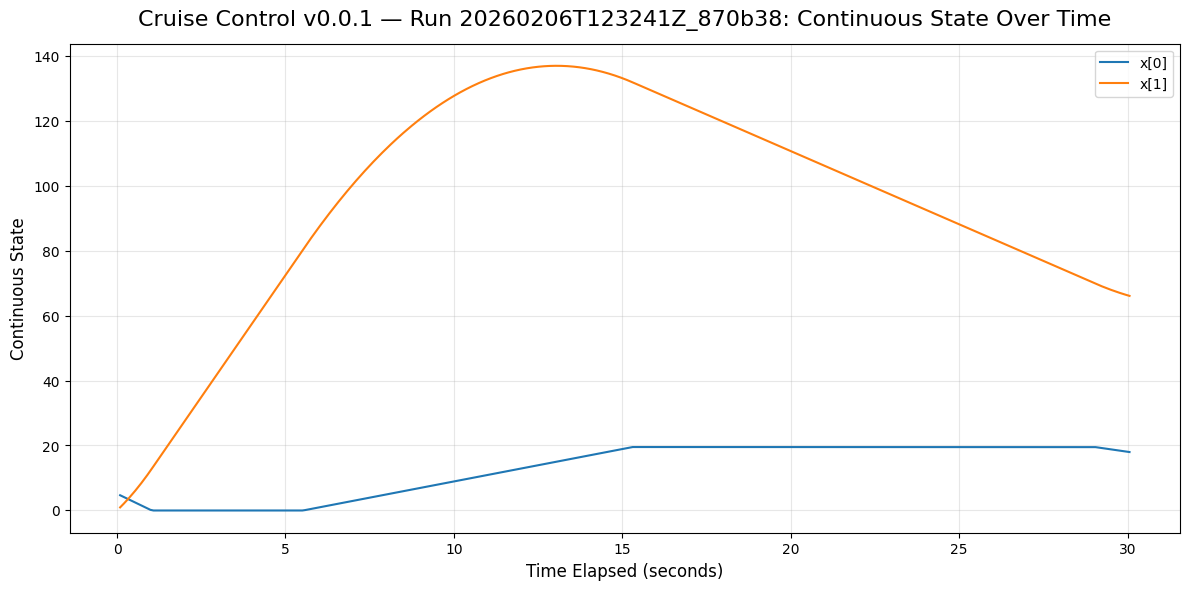

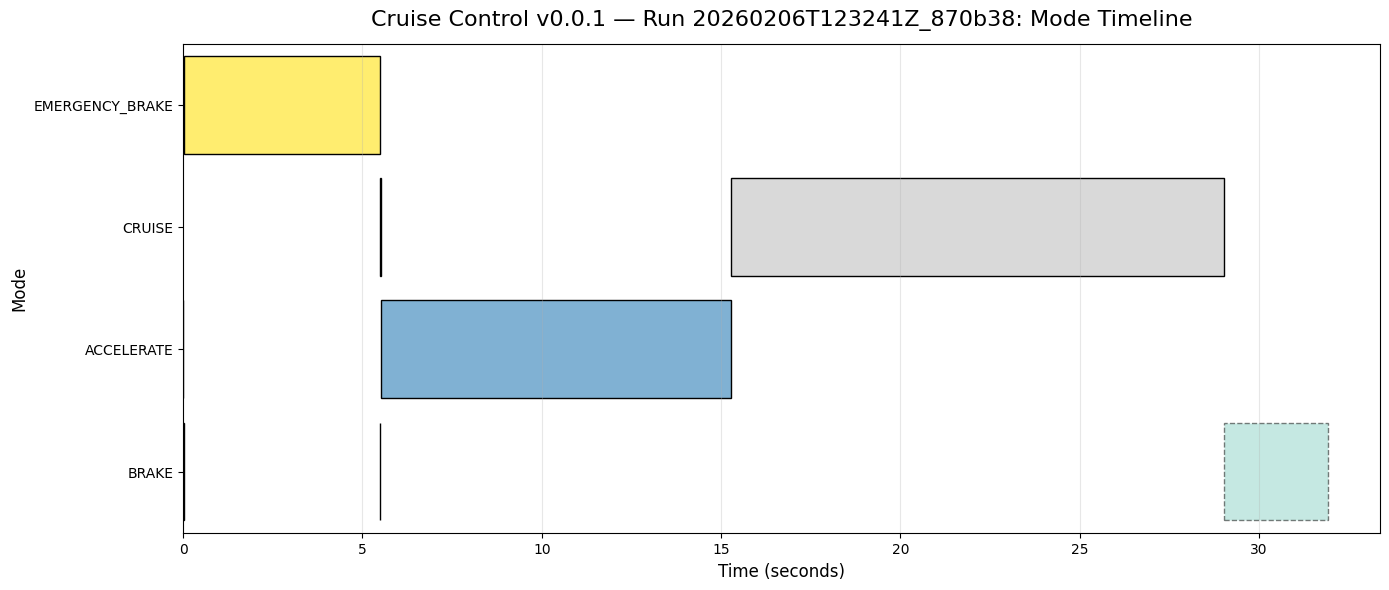

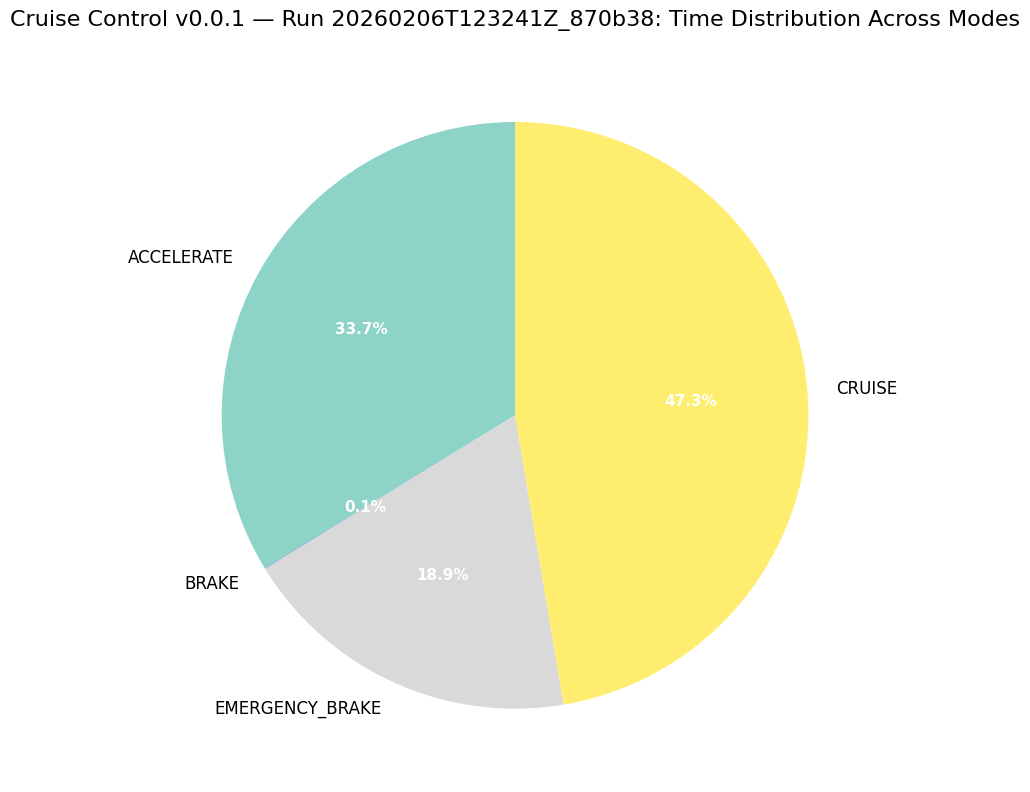

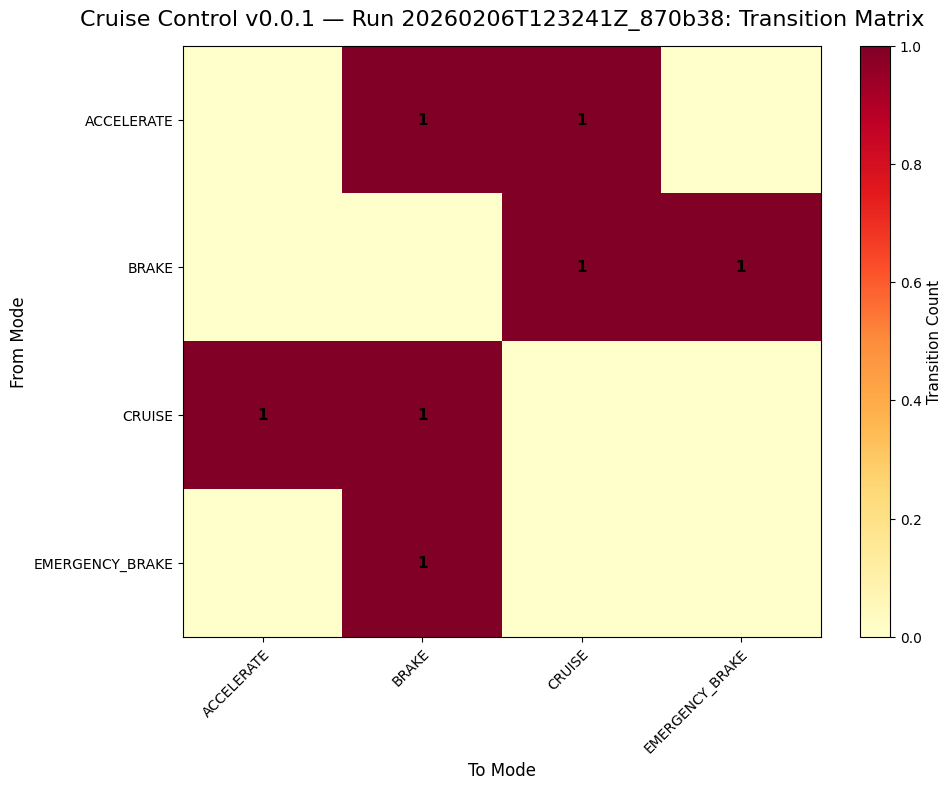

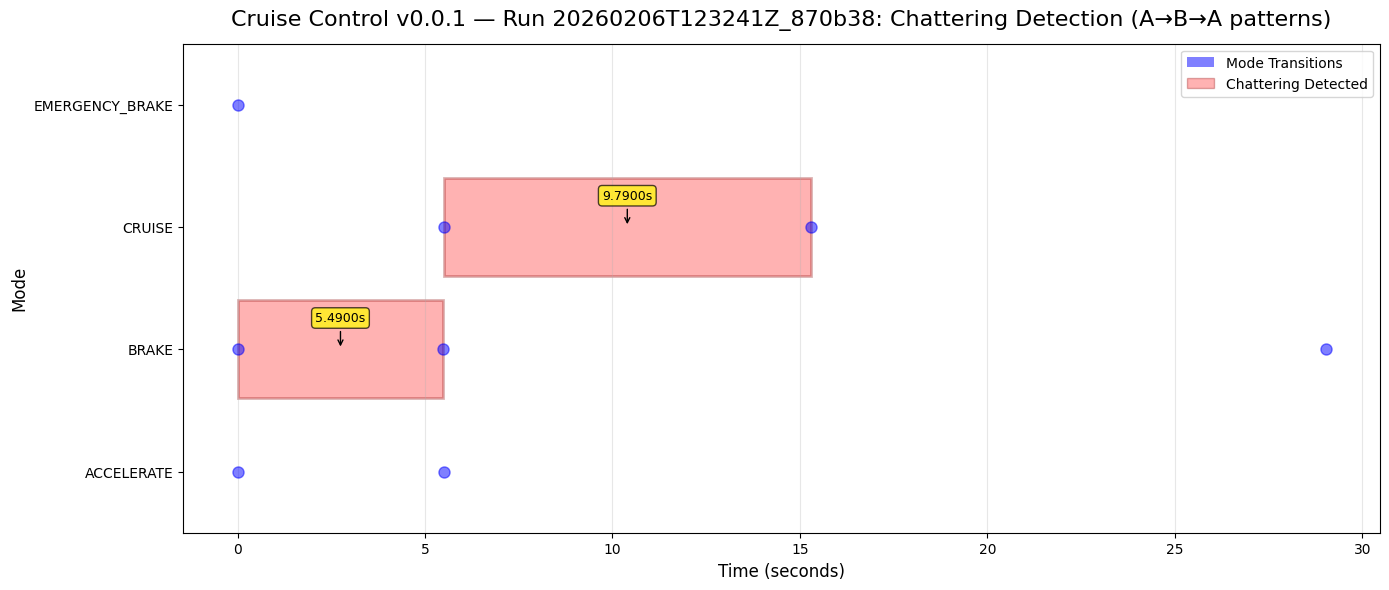

In [7]:
import matplotlib.pyplot as plt
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, mode_timeline_fig, mode_duration_pie_chart_fig, transition_matrix_heatmap_fig, chattering_detection_fig

fig1 = continuous_states_over_time_fig(run_result=results)
fig2 = mode_timeline_fig(run_result=results)
fig3 = mode_duration_pie_chart_fig(run_result=results)
fig4 = transition_matrix_heatmap_fig(run_result=results)
fig5 = chattering_detection_fig(run_result=results)

plt.show()